In [63]:
!pip install pandas
!pip install scikit-learn
!pip install torch
!pip install xgboost

Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 MB 12.8 MB/s eta 0:00:00m eta 0:00:010:00:01


## Tasks

### Evaluate the trained model on multiple metrics:
Directional accuracy (hit rate)

Root Mean Squared Error (RMSE)

Information coefficient (IC / correlation between prediction and true return)

etc.

### Plot graphs that analyze the model performance:

Bar Chart on overall model performance (X-axis: metrics, y-axis: metric values)

Per-stock Line Plot (X-axis: date, y-axis: y_pred, y_true, and error = y_pred - y_true)

Feel free to explore more graphs to plot!

# Imported Libraries

In [2]:
import numpy as np
import pandas as pd
import gc
import matplotlib.pyplot as plt
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
torch.set_num_threads(1)
torch.set_num_interop_threads(1)

# Data Formatting

In [3]:
# START TWEAKING DATA SIZE HERE
SEED = 100
np.random.seed(SEED)
torch.manual_seed(SEED)
nrows = 5124
DAYS_TO_PREDICT = 90
FEATURES = ["X1", "X2", "X3"]
TARGET = "y"
COLUMNS = FEATURES + [TARGET]
DAYS_TO_LOOKBACK = 1

# create a date range
dates = pd.date_range(start="1999-11-17", periods=nrows, freq="D")

# create a random dataframe
data = pd.DataFrame(np.random.randn(nrows, len(COLUMNS)), index=dates, columns=COLUMNS)

# create TimeSeriesSplit
tss = TimeSeriesSplit(n_splits=5, test_size=DAYS_TO_PREDICT, gap=DAYS_TO_LOOKBACK)


# Defined Functions from 05-lstm.ipynb

In [4]:
class MyLSTM(nn.Module):
    def __init__(self, base_params=None):
        super(MyLSTM, self).__init__()

        # Default hyperparameters
        defaults = {
            "input_dimension": len(FEATURES),
            "hidden_dimension": 8,
            "layer_dimension": 1,
            "output_dimension": 1,
            "dropout": 0.1,
            "lr": 1e-3,
            "num_epochs": 10,
            "gap": DAYS_TO_LOOKBACK,
        }
        
        # Merge user-supplied params with defaults
        if base_params is not None:
            defaults.update(base_params)
        self.params = defaults

        # Extract for convenience
        input_dim  = self.params["input_dimension"]
        hidden_dim = self.params["hidden_dimension"]
        num_layers = self.params["layer_dimension"]
        output_dim = self.params["output_dimension"]
        dropout    = self.params["dropout"]

        # --- Define LSTM layers ---
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x, h0=None, c0=None):
        """
        x: (B, L, F)
        """
        if h0 is None or c0 is None:
            h0 = torch.zeros(self.params["layer_dimension"], x.size(0), self.params["hidden_dimension"])
            c0 = torch.zeros(self.params["layer_dimension"], x.size(0), self.params["hidden_dimension"])

        out, _ = self.lstm(x, (h0, c0))     # out: (B, L, H)
        out = self.fc(out[:, -1, :])        # use last timestep
        return out.squeeze(-1)

def train_lstm(base_params=None, tss=None, data=None):
    import gc
    import numpy as np
    import pandas as pd
    import torch
    import torch.nn as nn
    from sklearn.metrics import mean_squared_error

    preds, tests, scores = [], [], []
    last_model = None

    for fold, (train_idx, test_idx) in enumerate(tss.split(data), 1):
        # --- Initialize model ---
        model = MyLSTM(base_params)
        learning_rate = (base_params or {}).get("lr", 0.001)
        criterion = nn.MSELoss()
        optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
        L = int(model.params["gap"])
        epochs = int(model.params["num_epochs"])

        # --- Prepare data ---
        train_df = data.iloc[train_idx]
        test_df  = data.iloc[test_idx]

        X_train = train_df[FEATURES].to_numpy(dtype=np.float32)
        y_train = train_df[TARGET].to_numpy(dtype=np.float32)
        X_test  = test_df[FEATURES].to_numpy(dtype=np.float32)
        y_test  = test_df[TARGET].to_numpy(dtype=np.float32)   

        # --- Training ---
        print(f"\n[Fold {fold}] Training...")
        model.train()
        for epoch in range(epochs):
            total_loss = 0.0
            for i in range(len(X_train) - L):
                # single sequence window and target
                x_seq = torch.as_tensor(X_train[i:i+L], dtype=torch.float32).unsqueeze(0)  # [1, L, D]
                y_t   = torch.as_tensor([y_train[i+L]], dtype=torch.float32)               # [1]

                optimizer.zero_grad(set_to_none=True)
                y_pred = model(x_seq).view(-1)  # flatten to [1]
                y_t = y_t.view(-1)              # flatten to [1]

                loss = criterion(y_pred, y_t)   
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
                total_loss += float(loss.detach())

            if (epoch + 1) % 5 == 0:
                avg = total_loss / max(len(X_train) - L, 1)     
                print(f"Epoch {epoch+1:3d} | Training MSE: {avg:.4f}")

        # --- Testing ---
        model.eval()
        preds_fold = []
        with torch.no_grad():
            for i in range(len(X_test) - L):
                x_seq = torch.as_tensor(X_test[i:i+L], dtype=torch.float32).unsqueeze(0)
                y_hat = model(x_seq).view(-1)[0].item()  # scalar prediction
                preds_fold.append(y_hat)

        # Align predictions and compute MSE
        idx = test_df.index[L:]
        y_test_seq = y_test[L:]
        y_pred_seq = np.array(preds_fold, dtype=np.float32)[:len(y_test_seq)]

        y_test_series = pd.Series(y_test_seq, index=idx)
        y_pred_series = pd.Series(y_pred_seq, index=idx)

        mse = mean_squared_error(y_test_series, y_pred_series)
        print(f"[Fold {fold}] Testing MSE = {mse:.4f}")

        preds.append(y_pred_series)
        tests.append(y_test_series)
        scores.append(mse)
        last_model = model
        gc.collect()

    return last_model, preds, tests, scores

# Run the Trained Model from 05-lstm.ipynb

In [5]:
model = MyLSTM()

reg, preds, tests, scores = train_lstm(tss=tss, data=data)


[Fold 1] Training...
Epoch   5 | Training MSE: 1.0186
Epoch  10 | Training MSE: 1.0182
[Fold 1] Testing MSE = 0.9932

[Fold 2] Training...
Epoch   5 | Training MSE: 1.0196
Epoch  10 | Training MSE: 1.0188
[Fold 2] Testing MSE = 1.0158

[Fold 3] Training...
Epoch   5 | Training MSE: 1.0194
Epoch  10 | Training MSE: 1.0186
[Fold 3] Testing MSE = 1.1057

[Fold 4] Training...
Epoch   5 | Training MSE: 1.0202
Epoch  10 | Training MSE: 1.0198
[Fold 4] Testing MSE = 1.0027

[Fold 5] Training...
Epoch   5 | Training MSE: 1.0208
Epoch  10 | Training MSE: 1.0200
[Fold 5] Testing MSE = 0.8162


# Calculate Metrics

Directional accuracy (hit rate)

Root Mean Squared Error (RMSE)

Information coefficient (IC / correlation between prediction and true return)

In [72]:
def outputMetrics(tests, preds):
    #Calculating Hit Rate
    hit_rate = np.mean(np.sign(tests) == np.sign(preds))
    
    #Calculating Root Mean Squared Error
    squared_sum = 0
    rmse = 0
    for i, val in preds.items():
        squared_sum += (tests[i] - val) **2
    rmse = np.sqrt(squared_sum / len(preds))
    
    #Calculating Information Coefficient
    ic = np.corrcoef(preds, tests)[0, 1]
    
    
    print(f"Calculated Hit Rate: {hit_rate}")
    print(f"Calculated Root Mean Squared Error: {rmse}")
    print(f"Calculated Information Coefficient: {ic}")

outputMetrics(tests[-1], preds[-1])

Calculated Hit Rate: 0.39325842696629215
Calculated Root Mean Squared Error: 0.9034503698348999
Calculated Information Coefficient: -0.12492667565117142


# Generating Graphs\

Bar Chart on overall model performance (X-axis: metrics, y-axis: metric values)

Per-stock Line Plot (X-axis: date, y-axis: y_pred, y_true, and error = y_pred - y_true)

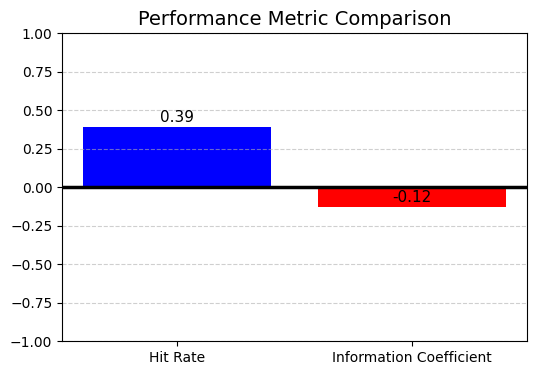

In [54]:
#Overall Model Performance
metrics = ['Hit Rate', 'Information Coefficient']
values = [hit_rate, ic]

plt.figure(figsize=(6, 4))
bars = plt.bar(metrics, values, color=['blue', 'red'])

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.01, f'{height:.2f}', 
             ha='center', va='bottom', fontsize=11)
plt.axhline(0, color='black', linewidth=2.5)
plt.title('Performance Metric Comparison', fontsize=14)
plt.ylim(-1, 1)
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.show()

# Per Stock Line Plot

## AAPL Line Plot


In [99]:
# import os
import xgboost as xgb
from sklearn.metrics import root_mean_squared_error

def find_project_root():
    search_dir = os.getcwd()
    for _ in range(5):
        if (os.path.exists(os.path.join(search_dir, 'data', 'processed', 'combined_stock_data.csv')) or
            os.path.exists(os.path.join(search_dir, 'experiment')) or
            os.path.exists(os.path.join(search_dir, 'README.md'))):
            return search_dir
        parent_dir = os.path.dirname(search_dir)
        if parent_dir == search_dir:
            break
        search_dir = parent_dir
    return os.getcwd()

FEATURES = ["Open", "Low", "High"]
TARGET = ["Close"]

def train_xgb(base_params=None, tss=None, data=None):

    # Use default one if user did not provide any hyperparameters
    if not base_params:
        base_params = {"n_estimators": 100, "early_stopping_rounds": 50, 
                       "max_depth": 3, "random_state":SEED, "objective":'reg:squarederror'}

    preds, tests = [], []
    scores = []
    for train_idx, test_idx in tss.split(data):
        train = data.iloc[train_idx]
        test = data.iloc[test_idx]
    
        X_train = train[FEATURES]
        y_train = train[TARGET]
        X_test = test[FEATURES]
        y_test = test[TARGET]
            
        reg = xgb.XGBRegressor(**base_params)
        reg.fit(X_train, y_train, eval_set=[(X_train,y_train), (X_test, y_test)], verbose=100)
        
        y_pred = reg.predict(X_test)
        y_pred = pd.Series(y_pred, index=y_test.index)
        
        tests.append(y_test)
        preds.append(y_pred)
        score = root_mean_squared_error(y_test, y_pred)
        scores.append(score)

    preds = pd.concat(preds).sort_index()
    tests = pd.concat(tests).sort_index()

    return reg, preds, tests, scores

project_root = find_project_root()
os.chdir(project_root)

FEATURES = ['open', 'high', 'low', 'close']
TARGET = ['log_return']

aapl_df = pd.read_csv("data/processed/AAPL_cleaned.csv")
aapl_tss = TimeSeriesSplit(n_splits = 5, test_size = 90, gap = 3)

aplReg, aplPreds, aplTests, aplScores = train_xgb(tss=aapl_tss, data=aapl_df)

#print(aplPreds[-1])
#print("Break")
#print(aplTests)

aplTests, aplPreds = aplTests.align(aplPreds, axis=1, copy = False)

outputMetrics(aplTests, aplPreds)

[0]	validation_0-rmse:0.02249	validation_1-rmse:0.01078
[97]	validation_0-rmse:0.00908	validation_1-rmse:0.01078
[0]	validation_0-rmse:0.02155	validation_1-rmse:0.01310
[99]	validation_0-rmse:0.00938	validation_1-rmse:0.01244
[0]	validation_0-rmse:0.02073	validation_1-rmse:0.01286
[99]	validation_0-rmse:0.00959	validation_1-rmse:0.00972
[0]	validation_0-rmse:0.02031	validation_1-rmse:0.01669
[99]	validation_0-rmse:0.00937	validation_1-rmse:0.01629
[0]	validation_0-rmse:0.02009	validation_1-rmse:0.01175
[97]	validation_0-rmse:0.01046	validation_1-rmse:0.01194
Calculated Hit Rate: 0.0
Calculated Root Mean Squared Error: 806    NaN
807    NaN
808    NaN
809    NaN
810    NaN
        ..
1251   NaN
1252   NaN
1253   NaN
1254   NaN
1255   NaN
Name: log_return, Length: 450, dtype: float64
Calculated Information Coefficient: nan
